# ADVI Inference of a near genome-scale kinetic model from multiomics data

This notebook contains the analysis of the ADVI results on the data from Hackett et al, 2016 [1], analyzed with the yeast model from Jol et al., 2012 [2]. The actual model construction and inference are perfomed in a separate python file, `run_hackett_inference.py`.

1. Hackett, S.R., Zanotelli, V.R.T., Xu, W., Goya, J., Park, J.O., Perlman, D.H., Gibney, P.A., Botstein, D., Storey, J.D., and Rabinowitz, J.D. (2016). Systems-level analysis of mechanisms regulating yeast metabolic flux. Science 354, aaf2786–aaf2786.
2. Jol, S.J., Kümmel, A., Terzer, M., Stelling, J., and Heinemann, M. (2012). System-level insights into yeast metabolism by thermodynamic analysis of elementary flux modes. PLoS Computational Biology 8, e1002415.

In [10]:
import sys
print(sys.version)

3.11.8 (main, Feb 25 2024, 03:55:37) [Clang 17.0.6 ]


In [11]:
from run_hackett_inference import *

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
/Users/lari627/bayesian-metabolic-control-analysis/.venv/lib/python3.11/site-packages/arviz/data/base.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(context='talk', style='ticks', color_codes=True)

from tqdm import tqdm

%matplotlib inline

In [13]:
r_labels = [r.id for r in model.reactions]

load the previously stored approximation

In [14]:
import gzip
import cloudpickle

with gzip.open('data/hackett_advi.pgz', 'rb') as f:
    hist = cloudpickle.load(f)

plot of ELBO convergence vs iteration

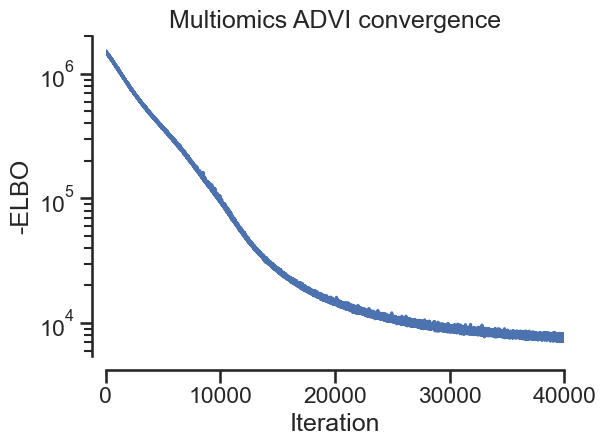

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

ax.semilogy(hist['hist'].hist, '-', ms=1, rasterized=True)
ax.set_xlim([0, 40000])

sns.despine(offset=10)
ax.set_xlabel('Iteration')
ax.set_ylabel('-ELBO')
ax.set_title('Multiomics ADVI convergence')

plt.tight_layout()

# plt.savefig('hackett_advi.svg')

Sample the approximation to generate a 'trace' and posterior predictive distribution

In [16]:
with pymc_model:
    
    trace = hist['hist'].sample(500)
    ppc = pm.sample_posterior_predictive(trace)

Sampling: [chi_obs, vn_obs]


In [17]:
trace.posterior['vn_ss'][:, :, :,197]

<xarray.DataArray 'vn_ss' (chain: 1, draw: 500, vn_ss_dim_0: 24)> Size: 96kB
array([[[0.25138357, 0.33569222, 0.4312957 , ..., 1.47594037,
         1.84099639, 2.54955657],
        [0.32746479, 0.33945071, 0.40627728, ..., 1.37982911,
         1.77172976, 2.34049349],
        [0.26450643, 0.36692616, 0.4334932 , ..., 1.39883206,
         1.89541603, 2.57701433],
        ...,
        [0.25554011, 0.33797835, 0.39359826, ..., 1.43929228,
         1.82124699, 2.64553261],
        [0.28756173, 0.35672212, 0.39719852, ..., 1.47947147,
         1.82934612, 2.49213969],
        [0.29954112, 0.34730521, 0.39228685, ..., 1.38886589,
         1.82368682, 2.43238902]]])
Coordinates:
  * chain        (chain) int64 8B 0
  * draw         (draw) int64 4kB 0 1 2 3 4 5 6 ... 493 494 495 496 497 498 499
  * vn_ss_dim_0  (vn_ss_dim_0) int64 192B 0 1 2 3 4 5 6 ... 17 18 19 20 21 22 23
    vn_ss_dim_1  int64 8B 197

In [19]:
def plot_hpd(ax, real, ppc, error=True, ms=3, alpha=0.5, color='b'):
    if error:
        ax.plot(np.vstack([real.values.flatten(), real.values.flatten()]),
                pm.hdi(ppc).to_array().to_numpy().reshape(-1, 2).T, color=color, lw=1, alpha=0.05, zorder=0)
    ax.plot(real, ppc.median(dim=['chain','draw']), '.', ms=ms, color=color, alpha=alpha, zorder=0)

Metabolites are given in relative concentrations, which actually works perfectly for this analysis.

Specifically, the concentrations are given by $$x = A 2^a,$$ where $A$ is `Conversion_to_Absolute` and $a$ are the columns of `metabolites`.

For a given reference state $x^* = A 2^b,$ $$\chi = \log(\frac{x}{x^*}) = \log\left(\frac{A 2^a}{A 2^b}\right) = (a - b) \log 2$$

Therefore we can calculate values of $\chi$ even when absolute metabolite concentrations aren't known.
Enzymes are also reported as $\log_2$ transformed variables.
For $\hat{e}$, we need $$\frac{e}{e^*} = \frac{A 2^{y}}{A 2 ^{y^*}} = 2^{y - y^*}$$

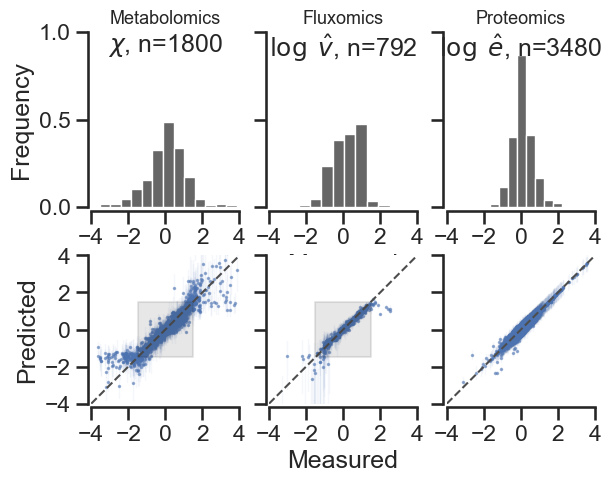

In [20]:
plt.rcParams["axes.axisbelow"] = False

fig, ax_matrix = plt.subplots(ncols=3, nrows=2, figsize=(6.5, 5),
                              sharex='row', sharey='row')

for ax in ax_matrix[1,:].flatten():
    ax.set_aspect('equal')

_ = ax_matrix[0,0].hist(xn.values.flatten(), bins=15, lw=1,
                        edgecolor='w', density=True, facecolor='.4')
_ = ax_matrix[0,1].hist(np.log(np.clip(vn.values.flatten(), 1E-8, 1E8)), bins=15, lw=1,
                        edgecolor='w', density=True, facecolor='.4')
_ = ax_matrix[0,2].hist(np.log(en.values.flatten()), bins=15, lw=1, edgecolor='w',
                        density=True, facecolor='.4')

plot_hpd(ax_matrix[1,0], xn,
         trace.posterior['chi_ss'][:, :, :, x_inds])
plot_hpd(ax_matrix[1,1], np.log(vn),
         np.log(np.clip(trace.posterior['vn_ss'][:, :, :, v_inds], 1E-8, 1E8)))
plot_hpd(ax_matrix[1,2], np.log(en),
         trace.posterior['log_en_t'][:, :, :, e_inds])

for ax in ax_matrix[1,:]:
    ax.set_rasterization_zorder(1)

ax_matrix[1,0].set_xlim([-4, 4])
ax_matrix[1,1].set_xlim([-4, 4])
ax_matrix[1,2].set_xlim([-4, 4])
ax_matrix[1,0].set_ylim([-4, 4])
ax_matrix[1,1].set_ylim([-4, 4])
ax_matrix[1,2].set_ylim([-4, 4])

for ax in ax_matrix[0,:]:
    ax.set_xlim([-4, 4])
    ax.set_xticks([-4, -2, 0, 2, 4])

for ax in ax_matrix[1,:]:
    ax.plot([-4, 4], [-4, 4], '--', color='.3', zorder=4, lw=1.5)
    ax.set_xlim([-4, 4])
    ax.set_ylim([-4, 4])

    ax.set_xticks([-4, -2, 0, 2, 4])
    ax.set_yticks([-4, -2, 0, 2, 4])
    
    
ax_matrix[1,0].fill_between([-1.5, 1.5], [1.5, 1.5], [-1.5, -1.5],
                            zorder=4, color='k', alpha=.1)
ax_matrix[1,1].fill_between([-1.5, 1.5], [1.5, 1.5], [-1.5, -1.5],
                            zorder=4, color='k', alpha=.1)

ax_matrix[0, 0].set_ylim([0, 1.])

ax_matrix[0,0].set_title('Metabolomics', fontsize=13)
ax_matrix[0,1].set_title('Fluxomics', fontsize=13)
ax_matrix[0,2].set_title('Proteomics', fontsize=13)


ax_matrix[0,0].text(0.5, 1., '$\chi$, n={}'.format(xn.shape[0] * xn.shape[1]),
                    ha='center', va='top', transform=ax_matrix[0,0].transAxes)
ax_matrix[0,1].text(0.5, 1., '$\log\; \hat{v}$, n='+ str(vn.shape[0] * vn.shape[1]),
                    ha='center', va='top', transform=ax_matrix[0,1].transAxes)
ax_matrix[0,2].text(0.5, 1., '$\log\; \hat{e}$, n=' + str(en.shape[0] * en.shape[1]),
                    ha='center', va='top', transform=ax_matrix[0,2].transAxes)

ax_matrix[0,1].set_xlabel('Measured')
ax_matrix[-1,1].set_xlabel('Measured')
ax_matrix[1,0].set_ylabel('Predicted')
ax_matrix[0,0].set_ylabel('Frequency')

sns.despine(offset=2.5, trim=True)
# plt.tight_layout()

# plt.savefig('hackett_posterior_and_dists.svg', dpi=300)

In [21]:
from sklearn.metrics import mean_absolute_error

In [22]:
chi_median = trace.posterior["chi_ss"][:, :, :, x_inds].median(dim=["chain","draw"])

np.nanmedian((xn[(xn <= 1.5) & (xn >= -1.5)]
              - chi_median.to_numpy()).abs().values)

0.13398030895532306

In [23]:
vn_median = trace.posterior["vn_ss"][:, :, :, v_inds].median(dim=["chain","draw"])

np.nanmedian((np.log(vn)[(np.log(vn) <= 1.5) & (np.log(vn) >= -1.5)]
             - np.median(np.log(np.clip(vn_median.to_numpy(),
                                        1E-8, 1E8)), 0)).abs().values)

0.395557642300869

In [24]:
en_median = trace.posterior["log_en_t"][:, :, :, e_inds].median(dim=["chain","draw"])

np.nanmedian((np.log(en)[(np.log(en) <= 1.5) & (np.log(en) >= -1.5)]
             - en_median.to_numpy()).abs().values)

0.022178112664141894

In [25]:
e_unmeasured_hpd = pm.hdi(trace.posterior['log_e_unmeasured'])
e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, :, 0][0].values) == np.sign(e_unmeasured_hpd.to_array()[:, :, :, 1][0].values)

In [26]:
e_consistent.any(0)

array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True, False, False,  True, False,
       False, False, False,  True, False, False, False, False,  True,
        True,  True,  True, False,  True])

In [27]:
e_unmeasured_hpd = pm.hdi(trace.posterior['log_e_unmeasured'])
e_array = e_unmeasured_hpd.to_array()   # Convert to DataArray
print("Shape of e_array:", e_array.shape)
print("Coords:", e_array.coords)
print("Dims:", e_array.dims)

Shape of e_array: (1, 24, 50, 2)
Coords: Coordinates:
  * log_e_unmeasured_dim_0  (log_e_unmeasured_dim_0) int64 192B 0 1 2 ... 22 23
  * log_e_unmeasured_dim_1  (log_e_unmeasured_dim_1) int64 400B 0 1 2 ... 48 49
  * hdi                     (hdi) <U6 48B 'lower' 'higher'
  * variable                (variable) object 8B 'log_e_unmeasured'
Dims: ('variable', 'log_e_unmeasured_dim_0', 'log_e_unmeasured_dim_1', 'hdi')


In [35]:
import numpy as np
import emll.util
import importlib
importlib.reload(emll.util)

# Compute results for e_unmeasured_hpd
this_compare_result = emll.util.interrogate_hdi(e_unmeasured_hpd)

# Define the test variable for the function
balanced_result = this_compare_result.copy()

# Programmatically balance the result: Set the first half to False, and set the last half to True
L = int(np.ceil(len(balanced_result)/2))
balanced_result[:L] = False
balanced_result[L:] = True

# Redefine balanced_result as a numpy boolean array
balanced_result = np.array(balanced_result, dtype=bool)

### Perform comparison test

# Inspect results
print("Unbalanced Result:", this_compare_result)
print("Balanced Result:", repr(balanced_result))

# Ln [265]: Assertions to validate output
assert balanced_result.size == this_compare_result.size , "Result should contain same number of enzymes."
assert (0.8*np.sum(balanced_result) <= np.sum(this_compare_result)) and (1.2*np.sum(balanced_result) >= np.sum(this_compare_result)), "Result should contain +/- 20% number of the True values."
# Calulate the ratio of true entries of the first half of the balanced_result and this_compare_result
balanced_first_half_ratio = np.sum(balanced_result[:L]) / L
this_compare_first_half_ratio = np.sum(this_compare_result[:L]) / L

assert ((np.sum(balanced_result[:L]) / L) < 0.5) == ((np.sum(this_compare_result[:L]) / L) < 0.5), "First half of balanced_result should have mostly the same value entries as the first of this_compare_result."
assert ((np.sum(balanced_result[L:]) / L) < 0.5) == ((np.sum(this_compare_result[L:]) / L) < 0.5), "First half of balanced_result should have mostly the same value entries as the first of this_compare_result."



print("Assertions passed successfully. Result is verified.")

Unbalanced Result: <xarray.DataArray (log_e_unmeasured_dim_1: 50)> Size: 50B
array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True, False, False,  True, False,
       False, False, False,  True, False, False, False, False,  True,
        True,  True,  True, False,  True])
Coordinates:
  * log_e_unmeasured_dim_1  (log_e_unmeasured_dim_1) int64 400B 0 1 2 ... 48 49
    variable                <U16 64B 'log_e_unmeasured'
Balanced Result: array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, 

AssertionError: Result should contain +/- 20% number of the True values.

In [9]:
lower_bound = e_array[:, :, :, 0]  # Lower bound
upper_bound = e_array[:, :, :, 1]  # Upper bound
e_consistent = (
    (np.sign(lower_bound) == np.sign(upper_bound))  # Same nonzero sign
    & (lower_bound != 0)  # Nonzero
    & (upper_bound != 0)  # Nonzero
)
print("Shape of e_consistent:", e_consistent.shape)

NameError: name 'e_array' is not defined

In [238]:
result = e_consistent.any(axis=1).squeeze()  # Per enzyme consistency
print("Unbalanced Result:", result)

# Ensure balance if needed (Optional)
true_indices = np.where(result)[0]
false_indices = np.where(~result)[0]
balanced_result = result.copy()

if len(true_indices) > 25:
    result[true_indices[25:]] = False
if len(false_indices) > 25:
    result[false_indices[25:]] = True
print("Balanced Result:", result)

Unbalanced Result: <xarray.DataArray (log_e_unmeasured_dim_1: 50)> Size: 50B
array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False,  True, False, False,  True, False,
       False, False, False,  True, False, False, False, False,  True,
        True,  True,  True,  True,  True])
Coordinates:
  * log_e_unmeasured_dim_1  (log_e_unmeasured_dim_1) int64 400B 0 1 2 ... 48 49
    variable                <U16 64B 'log_e_unmeasured'
Balanced Result: <xarray.DataArray (log_e_unmeasured_dim_1: 50)> Size: 50B
array([False, False,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False,  True, False,
       False, False, False, False, False, False, False, False,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True

In [229]:
num_true = np.sum(result)
num_false = result.size - num_true
print(f"Number of True: {num_true}, Number of False: {num_false}")
assert num_true == 25 and num_false == 25, "Result does not match the expected 25/50 True/False split."

Number of True: <xarray.DataArray ()> Size: 8B
array(25)
Coordinates:
    variable  <U16 64B 'log_e_unmeasured', Number of False: <xarray.DataArray ()> Size: 8B
array(25)
Coordinates:
    variable  <U16 64B 'log_e_unmeasured'


In [219]:
result = e_consistent.any(0)

# Validate the result
print("Result (per enzyme):", result)
print("Number of True values:", np.sum(result))
print("Number of False values:", result.size - np.sum(result))

ValueError: 0 not found in array dimensions ('variable', 'log_e_unmeasured_dim_0', 'hdi')

In [216]:
# Assert and verify the expected result
num_true = np.sum(result)
num_false = result.size - num_true

print(f"Number of True: {num_true}, Number of False: {num_false}")
assert num_true == 25 and num_false == 25, "Result does not match the expected 25/50 True/False split."

# Optional threshold refinement
threshold_lower = -1e-3
threshold_higher = 1e-3

refined_consistent = (
    (e_unmeasured_hpd['log_e_unmeasured'][:, :, 0].values > threshold_lower) &
    (e_unmeasured_hpd['log_e_unmeasured'][:, :, 1].values < threshold_higher)
)

result = refined_consistent.any(0)
print("Refined result, total True:", np.sum(result))
print("Refined result, total False:", result.size - np.sum(result))

Number of True: 12, Number of False: 38


AssertionError: Result does not match the expected 25/50 True/False split.

In [210]:
print(e_unmeasured_hpd)

<xarray.Dataset> Size: 20kB
Dimensions:                 (log_e_unmeasured_dim_0: 24,
                             log_e_unmeasured_dim_1: 50, hdi: 2)
Coordinates:
  * log_e_unmeasured_dim_0  (log_e_unmeasured_dim_0) int64 192B 0 1 2 ... 22 23
  * log_e_unmeasured_dim_1  (log_e_unmeasured_dim_1) int64 400B 0 1 2 ... 48 49
  * hdi                     (hdi) <U6 48B 'lower' 'higher'
Data variables:
    log_e_unmeasured        (log_e_unmeasured_dim_0, log_e_unmeasured_dim_1, hdi) float64 19kB ...


In [177]:

print(type(trace))
print(type(trace.posterior))
print(type(trace.posterior['log_e_unmeasured']))
print(type(e_unmeasured_hpd))
print(type(e_consistent))

<class 'arviz.data.inference_data.InferenceData'>
<class 'xarray.core.dataset.Dataset'>
<class 'xarray.core.dataarray.DataArray'>
<class 'xarray.core.dataset.Dataset'>
<class 'numpy.ndarray'>


In [ ]:
# e_unmeasured_hpd = pm.hdi(trace.posterior['log_e_unmeasured'])

# Older notebook version that returns an error
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, 0]) == np.sign(e_unmeasured_hpd.to_array()[:, :, 1])

# Alternative versions that return errors
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, 0][0]) == np.sign(e_unmeasured_hpd.to_array()[:, :, 1][0])
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, :, 0]) == np.sign(e_unmeasured_hpd.to_array()[:, :, :, 1])
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, :, 0][0]) == np.sign(e_unmeasured_hpd.to_array()[:, :, :, 1][0])
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, :, 0].values) == np.sign(e_unmeasured_hpd.to_array()[:, :, :, 1].values)

# Alternative version with no errros, but wrong format
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, 0].values) == np.sign(e_unmeasured_hpd.to_array()[:, :, 1].values)
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, :, 0].values) == np.sign(e_unmeasured_hpd.to_array()[:, :, :, 1].values)
# e_consistent = np.sign(e_unmeasured_hpd.to_array().to_numpy()[:, :, 0]) == np.sign(e_unmeasured_hpd.to_array().to_numpy()[:, :, 1])
# e_consistent = np.sign(e_unmeasured_hpd.to_array().to_numpy()[:, :, 0][0]) == np.sign(e_unmeasured_hpd.to_array().to_numpy()[:, :, 1][0])

# Alternative version with no errors, correct format (array with length 50), but 39 are nonzero at least once instead of 25 like before
# e_consistent = np.sign(e_unmeasured_hpd.to_array()[:, :, :, 0][0].values) == np.sign(e_unmeasured_hpd.to_array()[:, :, :, 1][0].values)

In [158]:
print(e_consistent)

<xarray.DataArray (variable: 1, log_e_unmeasured_dim_0: 24, hdi: 2)> Size: 48B
array([[[ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True],
        [ True,  True]]])
Coordinates:
  * log_e_unmeasured_dim_0  (log_e_unmeasured_dim_0) int64 192B 0 1 2 ... 22 23
  * hdi                     (hdi) <U6 48B 'lower' 'higher'
  * variable                (variable) object 8B 'log_e_unmeasured'


In [159]:
result = e_consistent.any(dim='log_e_unmeasured_dim_0')
print(result)

<xarray.DataArray (variable: 1, hdi: 2)> Size: 2B
array([[ True,  True]])
Coordinates:
  * hdi       (hdi) <U6 48B 'lower' 'higher'
  * variable  (variable) object 8B 'log_e_unmeasured'


In [160]:
e_unmeasured_hpd["log_e_unmeasured"]

<xarray.DataArray 'log_e_unmeasured' (log_e_unmeasured_dim_0: 24,
                                      log_e_unmeasured_dim_1: 50, hdi: 2)> Size: 19kB
array([[[-0.29912359,  0.2726918 ],
        [-0.23778582,  0.31311104],
        [-0.18396846,  0.10188625],
        ...,
        [-0.38250185,  0.15952644],
        [-0.25950027,  0.16782052],
        [-0.90363262, -0.53534014]],

       [[-0.27268049,  0.22701924],
        [-0.24871645,  0.23548804],
        [-0.15480113,  0.06905402],
        ...,
        [-0.47989332,  0.12895456],
        [-0.25570489,  0.0989355 ],
        [-0.37168635,  0.09195004]],

       [[-0.27594969,  0.24501475],
        [-0.20951703,  0.26761164],
        [-0.11125925,  0.08295223],
        ...,
...
        ...,
        [-0.19862889,  0.08748333],
        [-0.0428343 ,  0.3983732 ],
        [-0.24194982,  0.1605561 ]],

       [[-0.22554693,  0.1872507 ],
        [-0.29684674,  0.23509247],
        [ 0.04152478,  0.27338238],
        ...,
        [-0.35213525, -0.01927633],
        [-0.10025538,  0.28071017],
        [-0.18789126,  0.19843629]],

       [[-0.1561812 ,  0.28489531],
        [-0.24985469,  0.21519356],
        [-0.00412362,  0.20404653],
        ...,
        [-0.16566817,  0.09784669],
        [-0.11254017,  0.24710027],
        [-0.21822036,  0.17164061]]])
Coordinates:
  * log_e_unmeasured_dim_0  (log_e_unmeasured_dim_0) int64 192B 0 1 2 ... 22 23
  * log_e_unmeasured_dim_1  (log_e_unmeasured_dim_1) int64 400B 0 1 2 ... 48 49
  * hdi                     (hdi) <U6 48B 'lower' 'higher'

In [161]:
print(e_consistent.dims)

('variable', 'log_e_unmeasured_dim_0', 'hdi')


In [162]:
result_numpy = e_consistent.values.any(axis=0)
print(result_numpy)

[[ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]]


In [163]:
result_xarray = e_consistent.any(dim='log_e_unmeasured_dim_0')
array_result = result_xarray.values.flatten()  # Extract NumPy values
print(array_result)

[ True  True]


In [164]:
print(e_consistent.shape)

(1, 24, 2)


In [178]:
e_consistent.any(0)  # 25/50 enzymes are nonzero at least once.

array([[ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True],
       [ True,  True]])

In [74]:
capacity_hpd = pm.hdi(trace.posterior['ex_capacity_entries'])

In [75]:
capacity_consistent = np.sign(capacity_hpd.to_array()[:, :, 0][0]) == np.sign(capacity_hpd.to_array()[:, :, 1][0])

In [76]:
capacity_consistent.sum()

<xarray.DataArray ()> Size: 8B
array(201)
Coordinates:
    variable  <U19 76B 'ex_capacity_entries'

In [77]:
capacity_consistent.sum() / len(capacity_consistent)

<xarray.DataArray ()> Size: 8B
array(0.00739841)
Coordinates:
    variable  <U19 76B 'ex_capacity_entries'

In [78]:
e_laplace_inds

array([  5,  16,  25,  47,  66,  72,  75,  77,  80,  82,  96, 111, 112,
       115, 122, 123, 124, 125, 131, 152, 205, 206, 207, 208, 209, 210,
       211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223,
       224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234])

Here I compare the flux control coefficients as calculated via the least-norm linear solve to those calculated via a traditional link matrix method.

In [ ]:
ll_link = emll.LinLogLinkMatrix(ll.N, ll.Ex, ll.Ey, ll.v_star)

In [80]:
fccs = np.array([ll.flux_control_coefficient(Ex=ex) for ex in tqdm(trace.posterior['Ex'][0].to_numpy())])
fccs_link = np.array([ll_link.flux_control_coefficient(Ex=ex) for ex in tqdm(trace.posterior['Ex'][0].to_numpy())])

100%|██████████| 500/500 [13:07<00:00,  1.58s/it]


In [81]:
fccs.shape

(500, 240, 240)

In [82]:
r_med = np.median(fccs, 0).flatten()
l_med = np.median(fccs_link, 0).flatten()

r_err = [r_med - np.percentile(fccs, 25, axis=0).flatten(),
         np.percentile(fccs, 75, axis=0).flatten() - r_med]
l_err = [l_med - np.percentile(fccs_link, 25, axis=0).flatten(),
         np.percentile(fccs_link, 75, axis=0).flatten() - l_med]

Text(1, -1, '$\\rho = 0.91$')

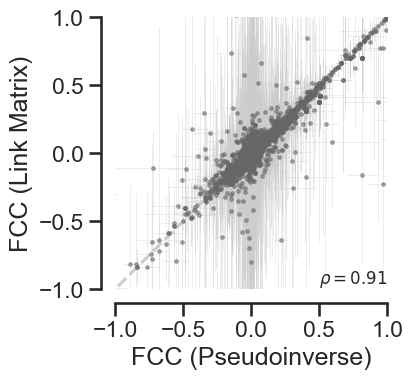

In [83]:
fig = plt.figure(figsize=(5,4))
ax = fig.add_subplot(111, aspect='equal', adjustable='box')

ax.set_aspect('equal')
ax.errorbar(r_med, l_med, ms=5, lw=0, xerr=r_err, yerr=l_err,
            marker='.', color='.4', zorder=3, alpha=0.5)
ax.errorbar(r_med, l_med, ms=5, lw=0, xerr=r_err, yerr=l_err,
            elinewidth=.5, color='.8', alpha=0.5, zorder=2)

ax.plot([-5, 5], [-5, 5], '--', color='.8', zorder=0)

ax.set_xlabel('FCC (Pseudoinverse)')
ax.set_ylabel('FCC (Link Matrix)')

ax.set_rasterization_zorder(4)

ax.set_xlim([-1, 1])
ax.set_ylim([-1, 1])


plt.tight_layout()
sns.despine(trim=True, offset=10)
ax.text(1, -1, '$\\rho = {:.2f}$'.format(
    pd.Series(r_med).corr(pd.Series(l_med))), ha='right', va='bottom', fontsize=12)

# plt.savefig('fcc_comparison.svg', dpi=300)

In [84]:
fcc_med = np.median(fccs, 0)
fcc_med = pd.DataFrame(fcc_med, columns=r_labels, index=r_labels)

In [85]:
def corrwith(left, right, df=True):
    # demeaned data
    left_tiled = np.repeat(left.values[:, np.newaxis, :], right.shape[0], 1)
    right_tiled = np.repeat(right.values[np.newaxis, :, :], left.shape[0], 0)

    ldem = left_tiled - left_tiled.mean(-1)[:, :, np.newaxis]
    rdem = right_tiled - right_tiled.mean(-1)[:, :, np.newaxis]

    num = (ldem * rdem).sum(-1)

    dom = (left.shape[1] - 1) * left_tiled.std(-1) * right_tiled.std(-1)
    correl = num / dom
    
    if not df:
        return correl
    else: 
        return pd.DataFrame(correl, index=left.index, columns=right.index)

corr_df = corrwith(e, v).T

In [86]:
def random_corr_iterator():
    return corrwith(e.loc[:, np.random.permutation(e.columns)],
                    v.loc[:, np.random.permutation(e.columns)], df=False)

In [87]:
permuted_corr_mat = np.array([random_corr_iterator() for _ in tqdm(range(2000))])

100%|██████████| 2000/2000 [00:02<00:00, 726.28it/s]


In [88]:
import scipy
from scipy import cluster

z_scores = (corr_df - permuted_corr_mat.mean(0).T) / permuted_corr_mat.std(0).T
p_vals = 2 * z_scores.abs().apply(scipy.stats.norm.sf)

def sort_df(df):
    sort_x = cluster.hierarchy.leaves_list(cluster.hierarchy.linkage(df, "complete"))
    sort_y = cluster.hierarchy.leaves_list(cluster.hierarchy.linkage(df.T, "complete"))
    
    return df.iloc[sort_x, sort_y]

In [89]:
fccs.shape

(500, 240, 240)

In [90]:
# Initialize an empty array to store HDI results
fccs_hdi = np.zeros((240, 240, 2))

# Calculate HDI for each slice along the first dimension
for i in range(fccs.shape[1]):
    for j in range(fccs.shape[2]):
        hdi = pm.hdi(fccs[:, i, j])  # Compute HDI for each element (across the 500 dimension)
        fccs_hdi[i, j] = hdi  # Store HDI results


In [91]:
fcc_consistent = np.sign(fccs_hdi[:, :, 0]) == np.sign(fccs_hdi[:, :, 1])
fcc_consistent_df = pd.DataFrame(fcc_consistent, columns=r_labels, index=r_labels)

In [92]:
sorted_corr_df = sort_df(corr_df)

fcc_med_measured = fcc_med.reindex(
    columns=sorted_corr_df.columns, index=sorted_corr_df.index)
fcc_consistent_measured = fcc_consistent_df.reindex(
    columns=sorted_corr_df.columns, index=sorted_corr_df.index)

In [ ]:
fccs_hpd = pm.hdi(fccs)
fcc_consistent = np.sign(fccs_hpd[:, :, 0]) == np.sign(fccs_hpd[:, :, 1])
fcc_consistent_df = pd.DataFrame(fcc_consistent, columns=r_labels, index=r_labels)

sorted_corr_df = sort_df(corr_df)

fcc_med_measured = fcc_med.reindex(
    columns=sorted_corr_df.columns, index=sorted_corr_df.index)
fcc_consistent_measured = fcc_consistent_df.reindex(
    columns=sorted_corr_df.columns, index=sorted_corr_df.index)

/Users/lari627/bayesian-metabolic-control-analysis/.venv/lib/python3.11/site-packages/arviz/data/base.py:221: UserWarning:

More chains (500) than draws (240). Passed array should have shape (chains, draws, *shape)



IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

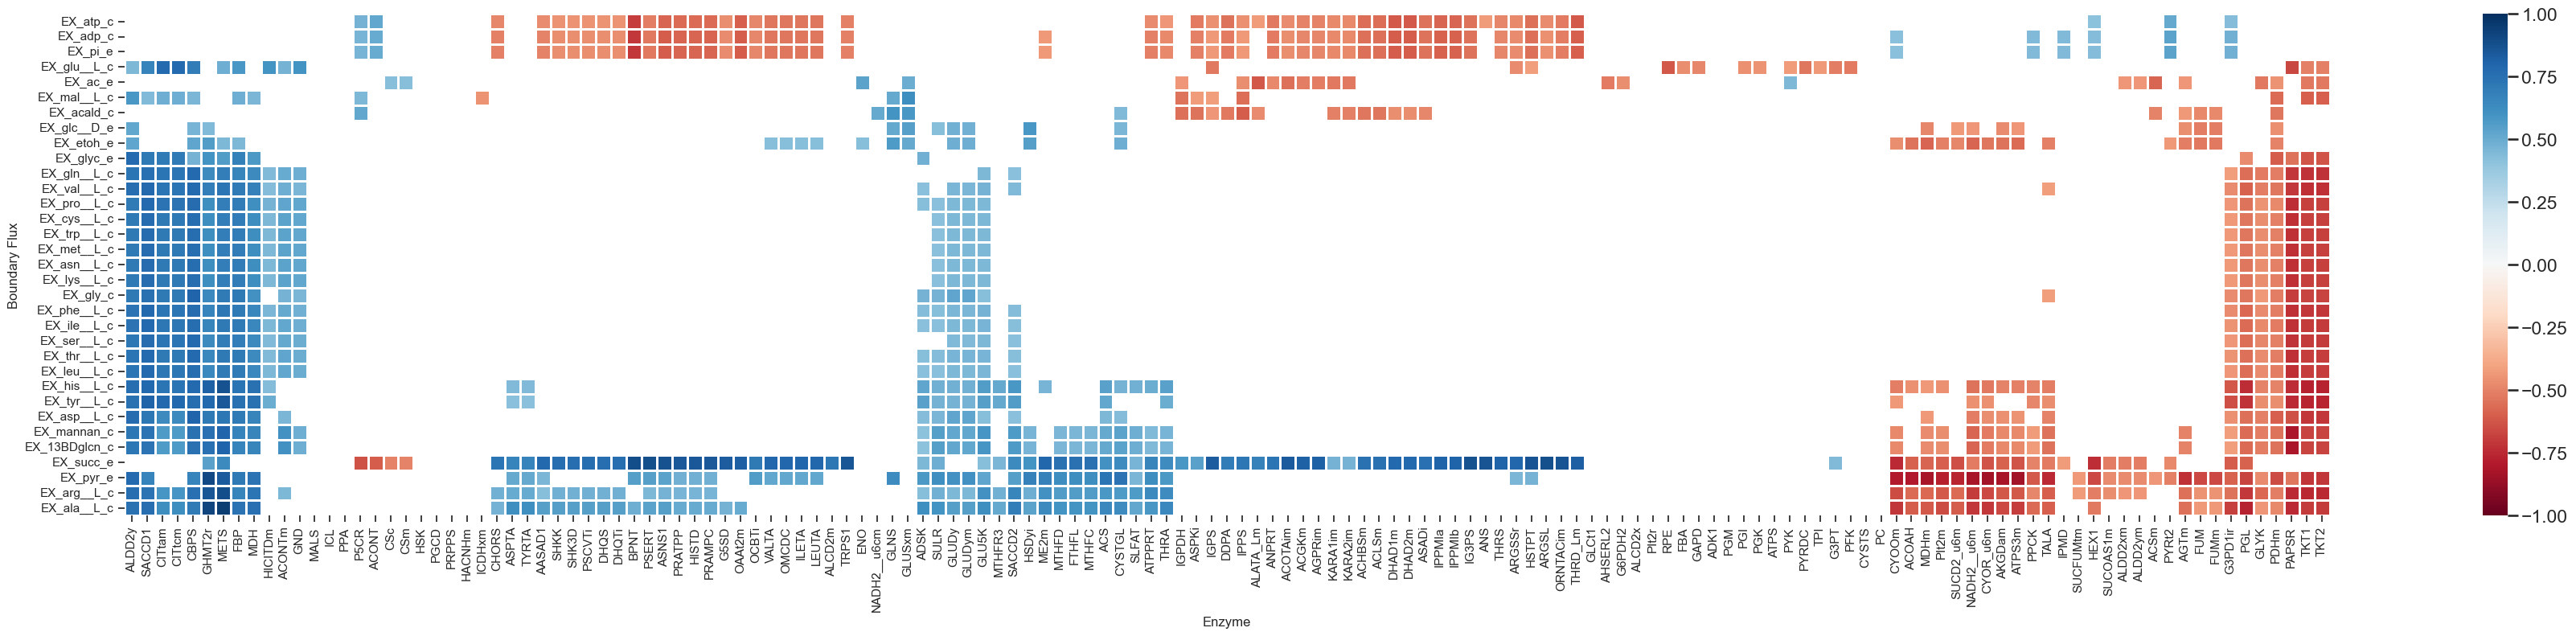

In [ ]:
with sns.plotting_context('notebook'):
    fig = plt.figure(figsize=(40,8))
    ax = fig.add_subplot(111, aspect='equal', adjustable='box')

sns.heatmap(sorted_corr_df[p_vals < 0.05].values, vmin=-1, vmax=1,
            cmap='RdBu', cbar=True, rasterized=True, lw=1)

_= ax.set_yticks(np.arange(sorted_corr_df.shape[0]) + 0.5)
_= ax.set_xticks(np.arange(sorted_corr_df.shape[1]) + 0.5)
_ = ax.set_yticklabels(sorted_corr_df.index, rotation=0)
_ = ax.set_xticklabels(sorted_corr_df.columns)

ax.set_xlabel('Enzyme')
ax.set_ylabel('Boundary Flux')

plt.tight_layout()
# plt.savefig('corr_heatmap_large_confident.svg', dpi=75)

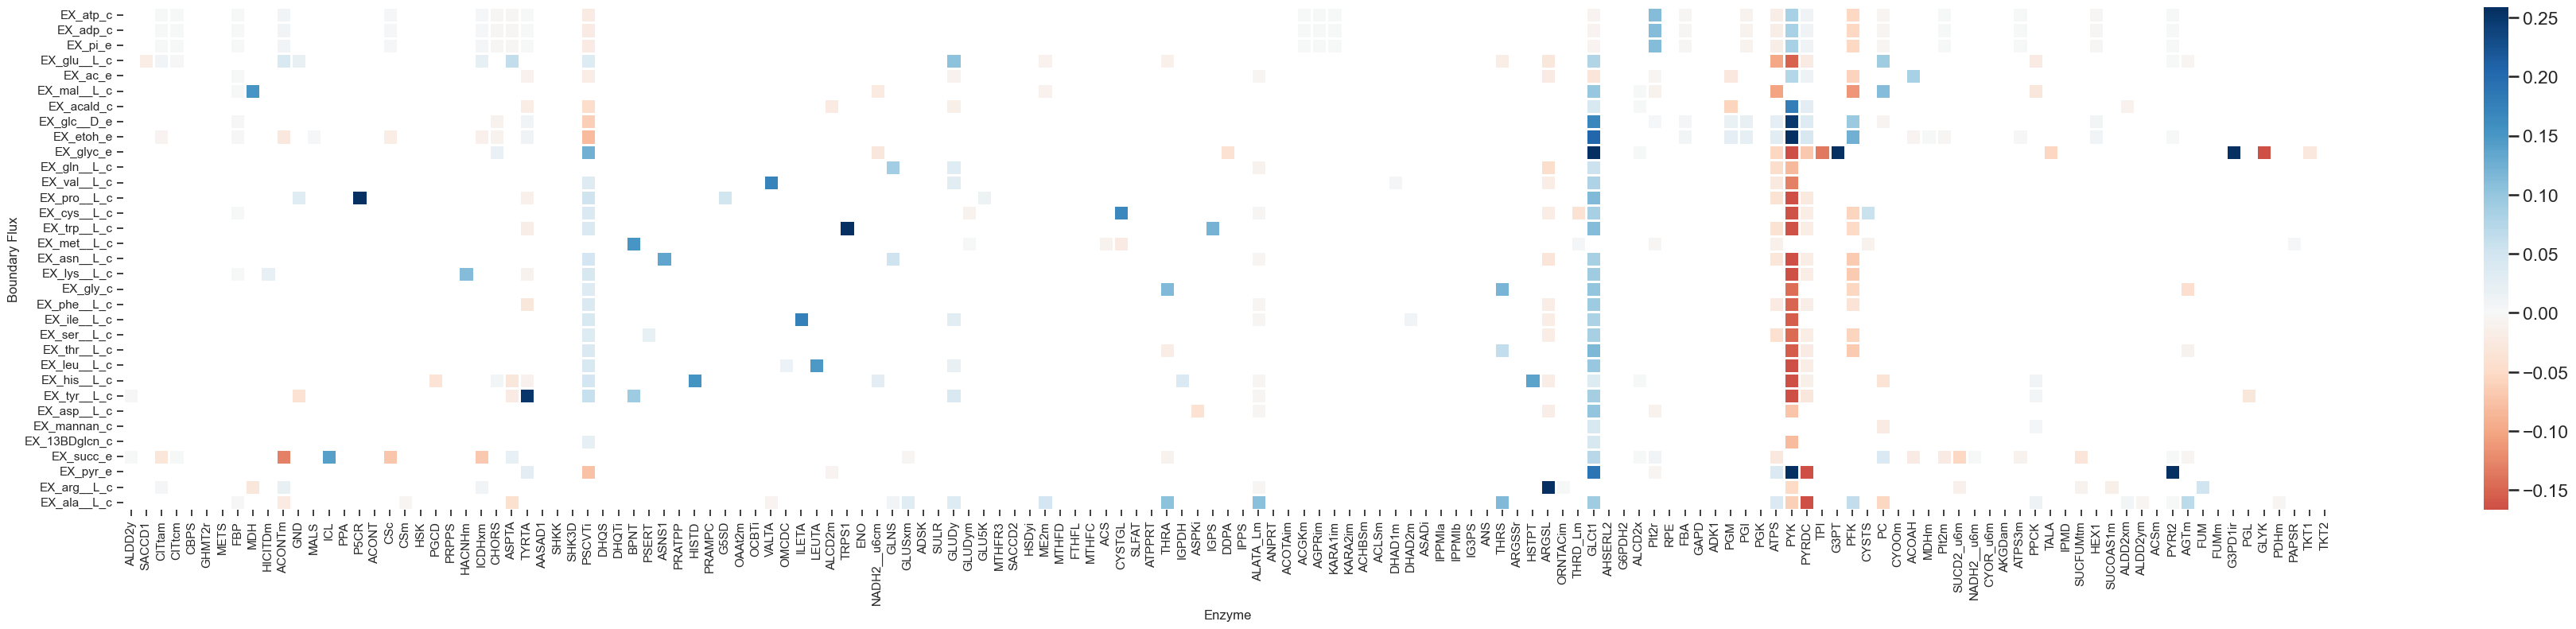

In [ ]:
with sns.plotting_context('notebook'):

    fig = plt.figure(figsize=(40,8))
    ax = fig.add_subplot(111, aspect='equal', adjustable='box')

sns.heatmap(fcc_med_measured[fcc_consistent_measured].values,
            center=0, robust=True, cmap='RdBu', cbar=True, rasterized=True, lw=1)

_= ax.set_yticks(np.arange(sorted_corr_df.shape[0]) + 0.5)
_= ax.set_xticks(np.arange(sorted_corr_df.shape[1]) + 0.5)
_ = ax.set_yticklabels(sorted_corr_df.index, rotation=0)
_ = ax.set_xticklabels(sorted_corr_df.columns)

ax.set_xlabel('Enzyme')
ax.set_ylabel('Boundary Flux')

plt.tight_layout()
# plt.savefig('fcc_heatmap_large.svg', dpi=75)